## Collecte et préparation des données

In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# chargement des données
fake_data_path = '../data/Fake.csv'
true_data_path = '../data/True.csv'

fake_df = pd.read_csv(fake_data_path)
true_df = pd.read_csv(true_data_path)

# affichage des premières lignes des données
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [3]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [4]:
# Ajouter les labels et combiner les datasets
fake_df['label'] = 'Fake'
true_df['label'] = 'Real'

# Concaténer les datasets
df = pd.concat([fake_df, true_df], ignore_index=True)

df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",Fake
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",Fake
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",Fake
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",Fake
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",Fake


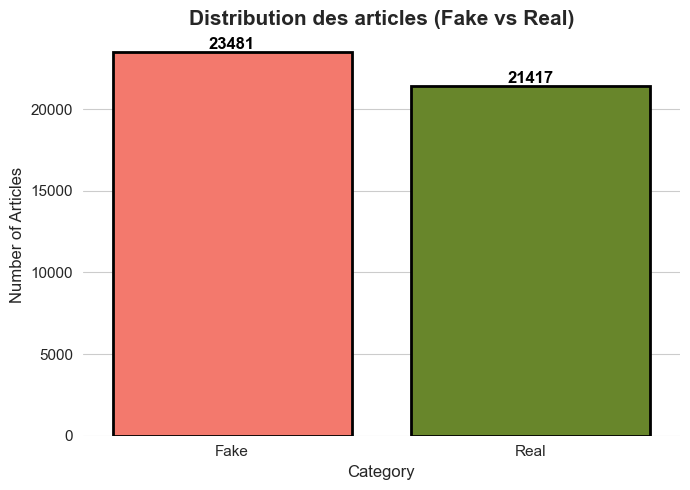

In [5]:
# Graphique 1 : Distribution des catégories (plus esthétique)
plt.figure(figsize=(7, 5))
palette = {'Fake': '#FF6F61', 'Real': '#6B8E23'}
sns.set_style("whitegrid")
ax = sns.countplot(
    x='label',
    hue='label',
    data=df,
    palette=palette,
    edgecolor='black',
    linewidth=2,
    saturation=0.85,
    legend=False
)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
plt.title('Distribution des articles (Fake vs Real)', fontsize=15, fontweight='bold')
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

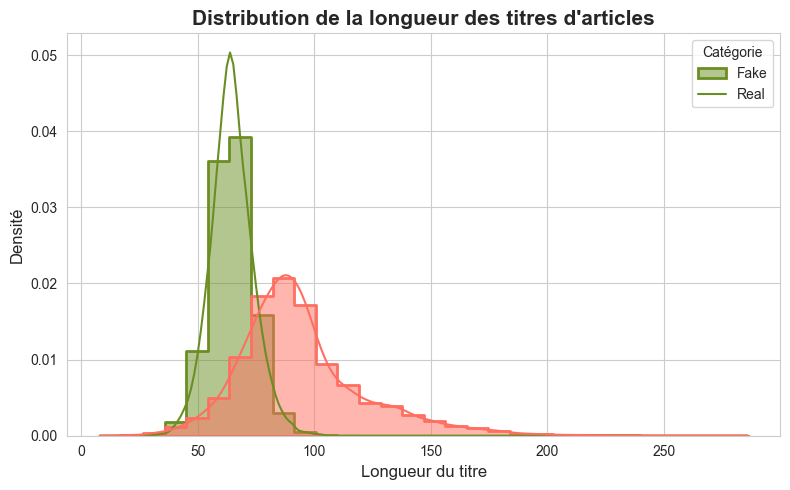

In [6]:
# Graphique 2 : Distribution de la longueur des titres selon la catégorie

# Calculer la longueur des titres
df['title_length'] = df['title'].apply(lambda x: len(str(x)))

plt.figure(figsize=(8, 5))
palette = {'Fake': '#FF6F61', 'Real': '#6B8E23'}

# Tracer la distribution avec un histogramme
ax = sns.histplot(
    data=df,
    x='title_length',
    hue='label',
    palette=palette,
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    linewidth=2,
    alpha=0.5
)

plt.title("Distribution de la longueur des titres d'articles", fontsize=15, fontweight='bold')
plt.xlabel("Longueur du titre", fontsize=12)
plt.ylabel("Densité", fontsize=12)
plt.legend(title="Catégorie", labels=["Fake", "Real"])
plt.tight_layout()
plt.show()

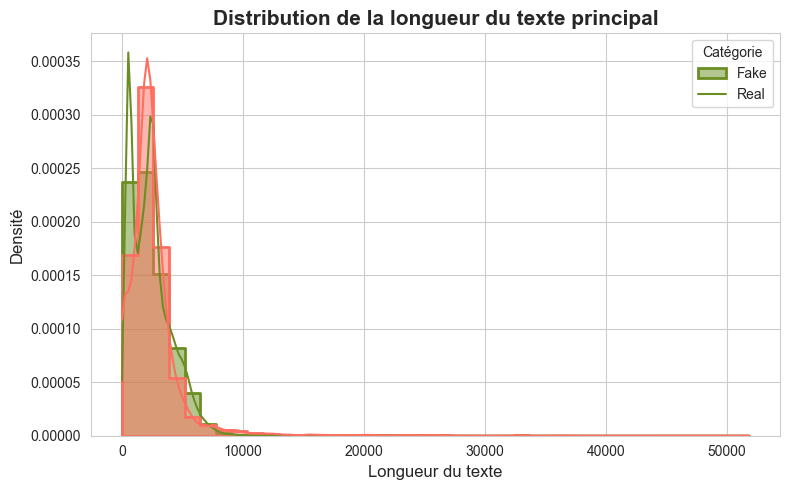

In [7]:
# Graphique 3 : Distribution de la longueur du texte principal selon la catégorie

# Calculer la longueur du texte principal
df['text_length'] = df['text'].apply(lambda x: len(str(x)))

plt.figure(figsize=(8, 5))
palette = {'Fake': '#FF6F61', 'Real': '#6B8E23'}

# Tracer la distribution avec un histogramme
ax = sns.histplot(
    data=df,
    x='text_length',
    hue='label',
    palette=palette,
    bins=40,
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    linewidth=2,
    alpha=0.5
)

plt.title("Distribution de la longueur du texte principal", fontsize=15, fontweight='bold')
plt.xlabel("Longueur du texte", fontsize=12)
plt.ylabel("Densité", fontsize=12)
plt.legend(title="Catégorie", labels=["Fake", "Real"])
plt.tight_layout()
plt.show()

In [8]:
import nltk
from collections import Counter
from wordcloud import STOPWORDS

#Télécharger les ressources NLTK
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/davidamouzou/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/davidamouzou/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [9]:
from nltk.corpus import stopwords

# Définir les stopwords (anglais)
stop_words = set(stopwords.words('english')).union(STOPWORDS)

def get_top_words(texts, n=20):
    words = []
    for text in texts:
        tokens = str(text).lower().split()
        tokens = [word.strip('.,!?;:"()[]') for word in tokens]
        tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
        words.extend(tokens)
    return Counter(words).most_common(n)

# Séparer les textes par catégorie
fake_texts = df[df['label'] == 'Fake']['text']
real_texts = df[df['label'] == 'Real']['text']

# Obtenir les 20 mots les plus fréquents pour chaque catégorie
top_fake = get_top_words(fake_texts, 20)
top_real = get_top_words(real_texts, 20)

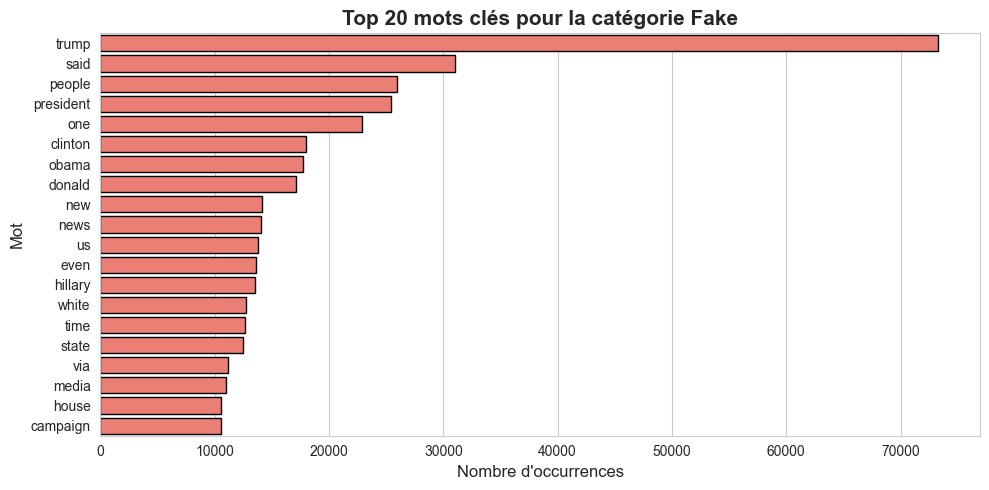

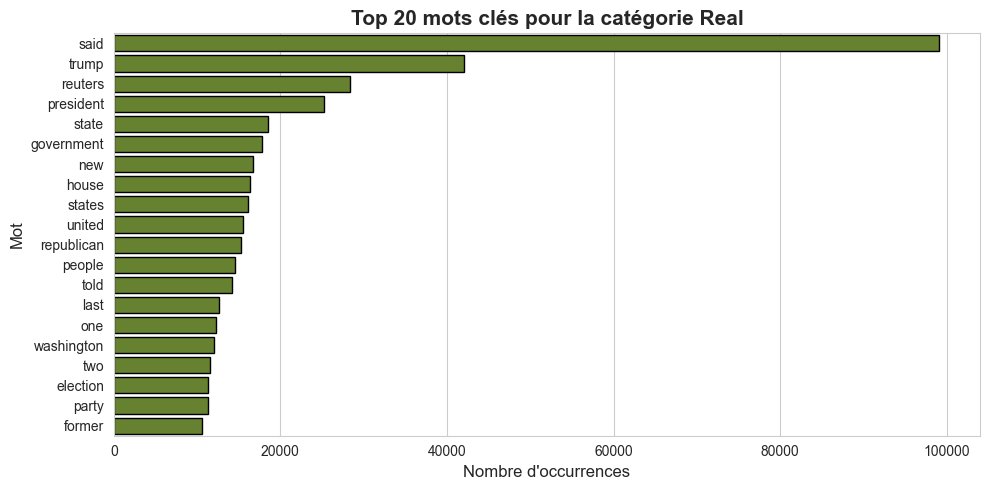

In [10]:
# Visualisation des 20 mots clés par catégorie avec un barplot

def plot_top_keywords_by_label(top_words, label, color):
    words, counts = zip(*top_words)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts), y=list(words), color=color, edgecolor='black')
    plt.title(f"Top 20 mots clés pour la catégorie {label}", fontsize=15, fontweight='bold')
    plt.xlabel("Nombre d'occurrences", fontsize=12)
    plt.ylabel("Mot", fontsize=12)
    plt.tight_layout()
    plt.show()

# Afficher pour Fake
plot_top_keywords_by_label(top_fake, "Fake", "#FF6F61")
# Afficher pour Real
plot_top_keywords_by_label(top_real, "Real", "#6B8E23")

## Préprocessing du texte

In [11]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [12]:
def preprocess_text(text):
    """Nettoie et préprocess le texte sans dépendre de word_tokenize (évite l'erreur punkt_tab)"""
    if pd.isna(text):
        return ""
    
    # Convertir en minuscules
    text = text.lower()
    
    # Supprimer les caractères spéciaux
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenisation simple (split sur les espaces)
    tokens = text.split()
    
    # Supprimer les stop words
    stop_words = set(stopwords.words('english'))  # ou 'french'
    tokens = [token for token in tokens if token not in stop_words]
    
    # Stemming
    stemmer = PorterStemmer()
    tokens = [stemmer.stem(token) for token in tokens]
    
    return ' '.join(tokens)

In [13]:
# Appliquer le préprocessing
df['text_processed'] = df['text'].apply(preprocess_text)
df['title_processed'] = df['title'].apply(preprocess_text)

#### Caractéristiques textuelles simples

In [14]:
from textstat import flesch_reading_ease, flesch_kincaid_grade

In [15]:
def extract_text_features(df):
    """Extrait des caractéristiques du texte"""
    
    # Longueur du texte
    df['text_length'] = df['text'].str.len()
    df['word_count'] = df['text'].str.split().str.len()
    
    # Caractéristiques de lisibilité
    df['flesch_score'] = df['text'].apply(lambda x: flesch_reading_ease(x) if pd.notna(x) else 0)
    df['flesch_kincaid'] = df['text'].apply(lambda x: flesch_kincaid_grade(x) if pd.notna(x) else 0)
    
    # Mots en majuscules (souvent dans fake news)
    df['caps_ratio'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)
    
    # Points d'exclamation et d'interrogation
    df['exclamation_count'] = df['text'].str.count('!')
    df['question_count'] = df['text'].str.count('\?')
    
    return df

df = extract_text_features(df)

In [16]:
# sauvegarder le dataset
df.to_csv('../data/df_processed.csv', index=False)